In [1]:
!pip install kaggle

In [2]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured.")

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key uploaded and configured.


In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:28<00:00, 86.3MB/s]



In [4]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [5]:
# List the contents of the unzipped directory to see the data structure
!ls -F  # Use -F to differentiate files and directories

chest_xray/  chest-xray-pneumonia.zip  sample_data/


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"
val_dir = "/content/chest_xray/val"

In [8]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


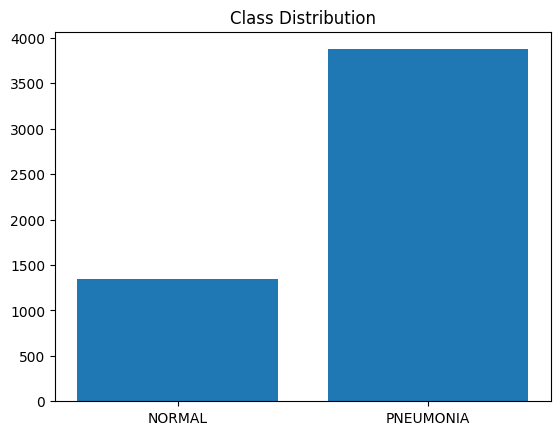

In [11]:
classes = os.listdir(train_dir)

normal_count = len(os.listdir(os.path.join(train_dir,"NORMAL")))
pneumonia_count = len(os.listdir(os.path.join(train_dir,"PNEUMONIA")))

plt.bar(
    ["NORMAL","PNEUMONIA"],
    [normal_count,pneumonia_count]
)

plt.title("Class Distribution")
plt.show()

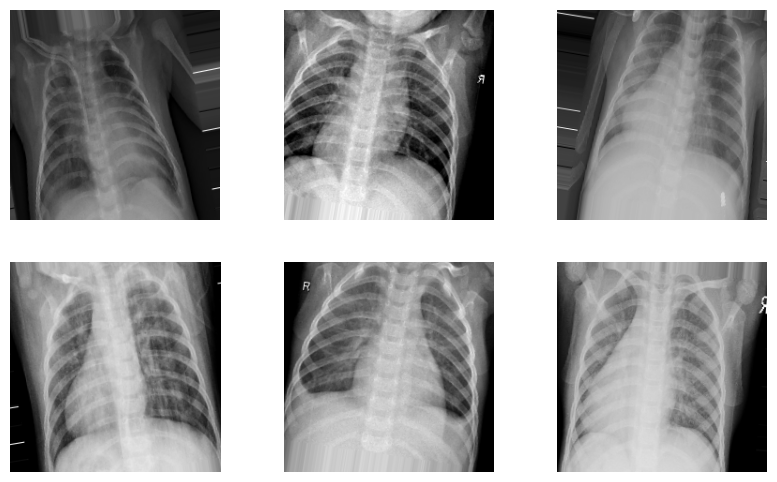

In [12]:
fig, ax = plt.subplots(2,3, figsize=(10,6))

for images, labels in train_generator:

    for i in range(6):
        ax.flat[i].imshow(images[i])
        ax.flat[i].axis("off")

    break

plt.show()

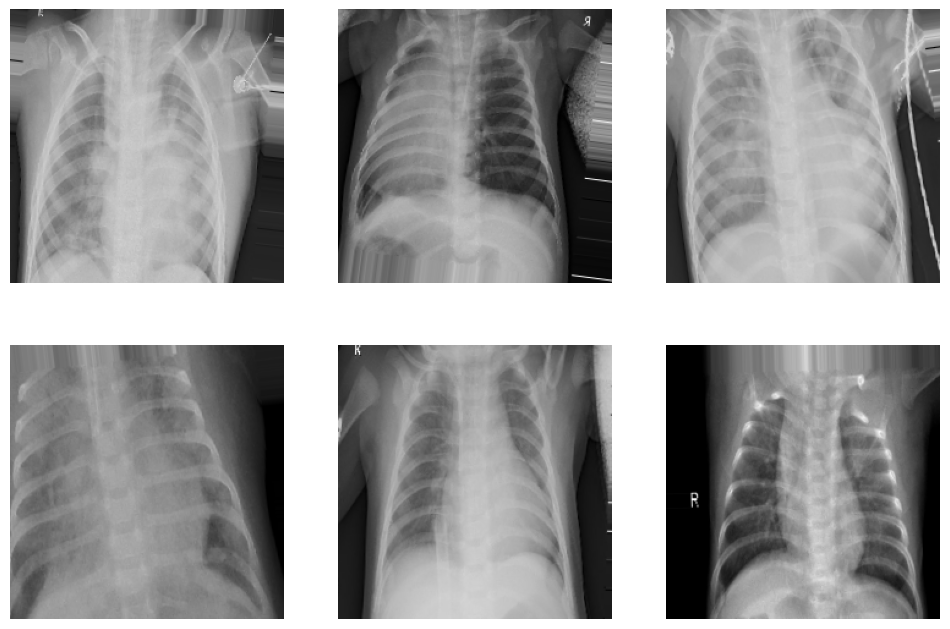

In [13]:
sample_img, _ = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(sample_img[i])
    plt.axis("off")

plt.show()

In [14]:
#TL

In [15]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [16]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 711ms/step - accuracy: 0.8298 - loss: 0.3764 - val_accuracy: 0.7500 - val_loss: 0.4809
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 616ms/step - accuracy: 0.8919 - loss: 0.2584 - val_accuracy: 0.8125 - val_loss: 0.4146
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.9066 - loss: 0.2298 - val_accuracy: 0.8750 - val_loss: 0.3520
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 618ms/step - accuracy: 0.9091 - loss: 0.2239 - val_accuracy: 0.8125 - val_loss: 0.3697
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 607ms/step - accuracy: 0.9189 - loss: 0.2078 - val_accuracy: 0.7500 - val_loss: 0.4479


In [20]:
base_model.trainable = True

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 305s 787ms/step - accuracy: 0.9523 - loss: 0.1256 - val_accuracy: 0.5000 - val_loss: 3.0550
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 709ms/step - accuracy: 0.9716 - loss: 0.0758 - val_accuracy: 0.9375 - val_loss: 0.1292
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 723ms/step - accuracy: 0.9795 - loss: 0.0570 - val_accuracy: 0.7500 - val_loss: 0.5527
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 734ms/step - accuracy: 0.9831 - loss: 0.0445 - val_accuracy: 1.0000 - val_loss: 0.0373
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 720ms/step - accuracy: 0.9835 - loss: 0.0433 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 717ms/step - accuracy: 0.9877 - loss: 0.0345 - val_accuracy: 1.0000 - val_loss: 0.0808
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 714ms/step - accuracy: 0.9885 - loss: 0.0284 - val_accuracy: 0.6250 - val_loss: 0.7451
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 697ms/step - accuracy: 0.9919 -

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import numpy as np

In [36]:
def evaluate_model(model, test_generator, model_name):

    test_generator.reset()

    # Probabilities
    y_prob = model.predict(test_generator)

    # Convert probabilities to predictions
    y_pred = (y_prob > 0.5).astype(int).flatten()

    # Actual labels
    y_true = test_generator.classes

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["NORMAL","PNEUMONIA"]
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

In [37]:
densenet_results = evaluate_model(
    model,
    test_generator,
    "DenseNet121"
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 844ms/step

===== DenseNet121 =====
Accuracy  : 0.9311
Precision : 0.9161
Recall    : 0.9795
F1 Score  : 0.9467
AUC-ROC   : 0.9719

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.96      0.85      0.90       234
   PNEUMONIA       0.92      0.98      0.95       390

    accuracy                           0.93       624
   macro avg       0.94      0.91      0.92       624
weighted avg       0.93      0.93      0.93       624



#VGG16

In [25]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [24]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

vgg_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [27]:
vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
history_vgg_frozen = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 186s 856ms/step - accuracy: 0.7331 - loss: 0.6148 - val_accuracy: 0.5000 - val_loss: 0.9182
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 878ms/step - accuracy: 0.7502 - loss: 0.5208 - val_accuracy: 0.7500 - val_loss: 0.5087
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 802ms/step - accuracy: 0.8489 - loss: 0.3265 - val_accuracy: 0.8750 - val_loss: 0.3847
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 795ms/step - accuracy: 0.8854 - loss: 0.2627 - val_accuracy: 0.8125 - val_loss: 0.2767
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 791ms/step - accuracy: 0.9051 - loss: 0.2198 - val_accuracy: 0.8125 - val_loss: 0.2854


In [29]:
base_model.trainable = True

In [30]:
import tensorflow as tf

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history_vgg_finetune = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 797ms/step - accuracy: 0.9243 - loss: 0.1830 - val_accuracy: 0.7500 - val_loss: 0.6056
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 796ms/step - accuracy: 0.9381 - loss: 0.1588 - val_accuracy: 0.7500 - val_loss: 0.5032
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 806ms/step - accuracy: 0.9446 - loss: 0.1461 - val_accuracy: 0.7500 - val_loss: 0.7822
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 812ms/step - accuracy: 0.9394 - loss: 0.1505 - val_accuracy: 0.7500 - val_loss: 1.1012
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 802ms/step - accuracy: 0.9438 - loss: 0.1391 - val_accuracy: 0.6875 - val_loss: 1.0413
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 823ms/step - accuracy: 0.9515 - loss: 0.1305 - val_accuracy: 0.7500 - val_loss: 0.6116
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 831ms/step - accuracy: 0.9544 - loss: 0.1188 - val_accuracy: 0.7500 - val_loss: 0.9181
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 820ms/step - accuracy: 0.9553 -

In [32]:
vgg_model.save("vgg16_pneumonia.keras")

In [46]:
model.save("densenet121_pneumonia.keras")

In [47]:
cnn.save("cnn_pneumonia.keras")

In [38]:
vgg_results = evaluate_model(
    vgg_model,
    test_generator,
    "VGG16"
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step

===== VGG16 =====
Accuracy  : 0.8590
Precision : 0.8283
Recall    : 0.9769
F1 Score  : 0.8965
AUC-ROC   : 0.9490

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.95      0.66      0.78       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624



In [39]:
test_loss, test_acc = vgg_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.8590 - loss: 0.4477
Test Accuracy: 0.8590


#CNN

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [41]:
cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history_cnn = cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 630ms/step - accuracy: 0.8035 - loss: 0.4558 - val_accuracy: 0.8125 - val_loss: 0.5626
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 610ms/step - accuracy: 0.8737 - loss: 0.3040 - val_accuracy: 0.8750 - val_loss: 0.4032
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 619ms/step - accuracy: 0.8988 - loss: 0.2497 - val_accuracy: 0.7500 - val_loss: 0.5789
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.9053 - loss: 0.2322 - val_accuracy: 0.8750 - val_loss: 0.4659
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 622ms/step - accuracy: 0.9158 - loss: 0.2249 - val_accuracy: 0.6875 - val_loss: 0.7945
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 616ms/step - accuracy: 0.9225 - loss: 0.2007 - val_accuracy: 0.6250 - val_loss: 0.9739
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.9222 - loss: 0.2043 - val_accuracy: 0.6875 - val_loss: 0.8010
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 611ms/step - accuracy: 0.9279 - 

In [44]:
cnn_results = evaluate_model(
    cnn,
    test_generator,
    "CNN"
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step

===== CNN =====
Accuracy  : 0.8542
Precision : 0.8215
Recall    : 0.9795
F1 Score  : 0.8936
AUC-ROC   : 0.9622

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.95      0.65      0.77       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.85       624



In [45]:
import pandas as pd

results_df = pd.DataFrame([
    densenet_results,
    vgg_results,
    cnn_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,DenseNet121,0.931090,0.916067,0.979487,0.946716,0.971861
1,VGG16,0.858974,0.828261,0.976923,0.896471,0.948975
2,CNN,0.854167,0.821505,0.979487,0.893567,0.962229


In [48]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [49]:
model = load_model("densenet121_pneumonia.keras")

In [50]:
for layer in model.layers:
    print(layer.name)

input_layer
zero_padding2d
conv1_conv
conv1_bn
conv1_relu
zero_padding2d_1
pool1
conv2_block1_0_bn
conv2_block1_0_relu
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_concat
conv2_block2_0_bn
conv2_block2_0_relu
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_concat
conv2_block3_0_bn
conv2_block3_0_relu
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_concat
conv2_block4_0_bn
conv2_block4_0_relu
conv2_block4_1_conv
conv2_block4_1_bn
conv2_block4_1_relu
conv2_block4_2_conv
conv2_block4_concat
conv2_block5_0_bn
conv2_block5_0_relu
conv2_block5_1_conv
conv2_block5_1_bn
conv2_block5_1_relu
conv2_block5_2_conv
conv2_block5_concat
conv2_block6_0_bn
conv2_block6_0_relu
conv2_block6_1_conv
conv2_block6_1_bn
conv2_block6_1_relu
conv2_block6_2_conv
conv2_block6_concat
pool2_bn
pool2_relu
pool2_conv
pool2_pool
conv3_block1_0_bn
conv3_block1_0_relu
conv3_block1_1_conv
con

In [51]:
IMG_SIZE = (224,224)

img_path = "/content/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"

img = image.load_img(
    img_path,
    target_size=IMG_SIZE
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [52]:
prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    print(f"PNEUMONIA ({prediction*100:.2f}%)")
else:
    print(f"NORMAL ({(1-prediction)*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
PNEUMONIA (99.99%)


In [53]:
last_conv_layer = model.get_layer(
    "conv5_block16_concat"
)

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        last_conv_layer.output,
        model.output
    ]
)

In [55]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, 0]

grads = tape.gradient(
    loss,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap = heatmap / np.max(heatmap)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


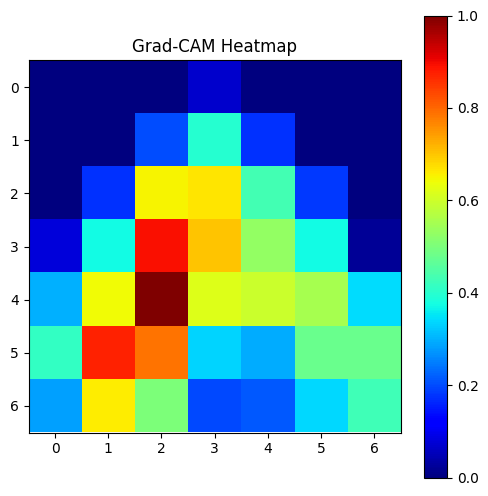

In [56]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

In [57]:
original_img = cv2.imread(img_path)

original_img = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)

heatmap_resized = cv2.resize(
    heatmap,
    (
        original_img.shape[1],
        original_img.shape[0]
    )
)

heatmap_colored = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_colored,
    0.4,
    0
)

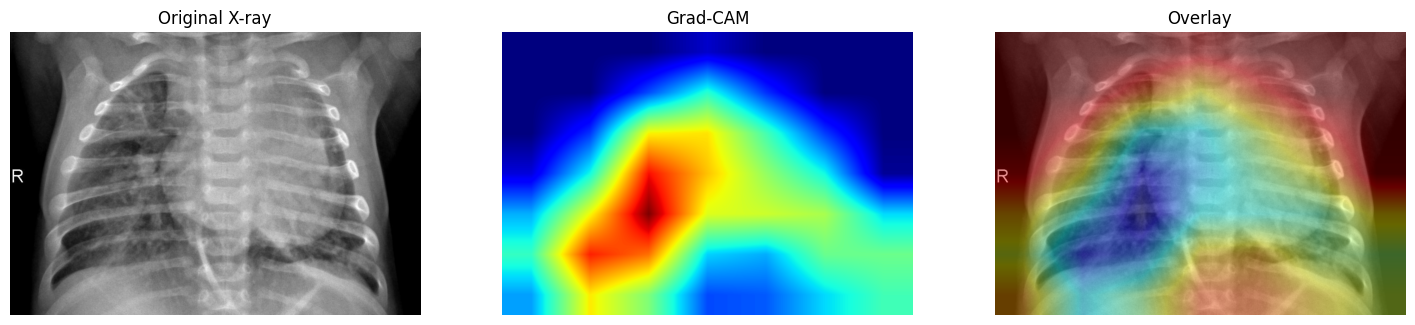

In [58]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(original_img)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

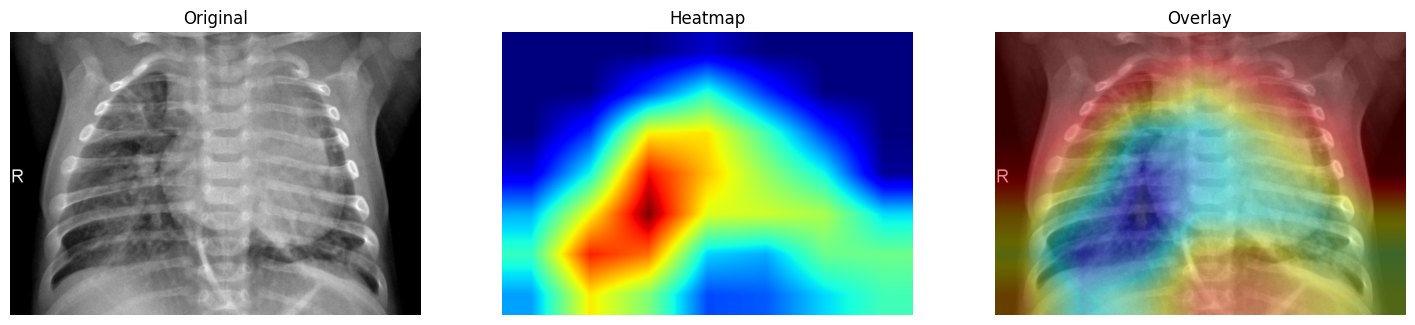

In [59]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(original_img)
plt.axis("off")
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap="jet")
plt.axis("off")
plt.title("Heatmap")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.axis("off")
plt.title("Overlay")

plt.savefig(
    "gradcam_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()